# 🌲🔥 Forest Fire Points Extraction Pipeline — GPU Accelerated
## Reference: Biswas et al. (2025) & Uthappa et al. (2025)

**Study period:** 1 Nov 2000 – 15 Dec 2022
**Methodology:** Extract forest fire points from MODIS Collection 6.1 data
by filtering against ESA-CCI / C3S LULC forest classes (Sannigrahi et al., 2018)

**Scope of this notebook:** preprocessing only — merging/cleaning the MODIS fire
archive, building yearly forest masks from LULC, and extracting forest fire points
(annual + monthly CSVs). No downstream ML/analysis here.

**GPU:** the per-year forest-mask build and point-in-pixel lookup (the actual
compute bottleneck — ~124M-pixel LULC grid × up to ~300k fire points/year × 22 years)
run on GPU via CuPy. CSV I/O and date parsing stay on CPU/pandas since CuPy has no
string/datetime support — that part is not the bottleneck.

---
### Data locations (all local to this project folder)
| Data | Path |
|------|------|
| MODIS fire archive (FIRMS, 2000-11-01 to 2022-12-15) | `fire_archive_M-C61_772720.csv` |
| LULC (ESA-CCI / C3S ZIP files, 1992–2022) | `LAND USE- LAND COVER DATA(india)/` |
| India boundary (plot outline + exact fire-point clip) | `India_State_Boundary.shp` (dissolved) |
| Outputs | `Forest_Fire_Outputs/` |

### Design notes vs. the previous version of this notebook
- **Study period is capped at 2022-12-15** — ESA-CCI/C3S LULC (land cover) data
  does not exist past 2022 on this machine or from the standard source, so fire
  points after that date cannot be forest-filtered against real land-cover data.
- **Fire points are clipped to India's actual polygon, not just a lon/lat
  bounding box.** A rectangular bbox (68–97.5°E, 6.5–37.5°N) also covers Sri
  Lanka, southern Pakistan, Nepal, Bangladesh, and Myanmar — all high-fire-activity
  regions — so a bbox-only filter silently pulls in a large number of non-Indian
  fire detections. Step 4 loads the India boundary polygon and Step 5 uses an
  exact point-in-polygon test (`shapely.contains_xy`) to exclude them.
- The old notebook had two parallel extraction methods (a fast approximate
  nearest-pixel lookup, and an unexecuted rasterio/geopandas raster→vector→spatial-join
  method). This version keeps **one** method: an *exact* regular-grid pixel lookup
  (affine math, not nearest-neighbor search) — mathematically exact for ESA-CCI's
  regular lat/lon grid, and trivially portable to GPU via CuPy. The vector/spatial-join
  path is dropped (shapely/geopandas spatial joins are CPU-only on native Windows).
- Duplicate/dead debug cells from the old notebook are removed.


## 📦 Step 0 — Install Required Libraries
Run once. `cupy-cuda12x` + the NVIDIA JIT-header packages enable GPU acceleration.
If CuPy fails to install/import, the pipeline automatically falls back to CPU (NumPy) —
still correct, just slower.


In [ ]:
import subprocess, sys

packages = [
    "geopandas",
    "netCDF4",
    "numpy",
    "pandas",
    "matplotlib",
    "tqdm",
    "pyogrio",
    # GPU acceleration (native Windows — no WSL required)
    "cupy-cuda12x",
    "nvidia-cuda-runtime-cu12",
    "nvidia-cuda-nvrtc-cu12",
    "nvidia-cuda-nvcc-cu12",
]

for pkg in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    except subprocess.CalledProcessError as e:
        print(f"WARNING: failed to install {pkg} ({e}) — continuing")

print("Library installation complete.")


Library installation complete.


## 📚 Step 1 — Imports & GPU Detection

In [ ]:
import os
import re
import time
import zipfile
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import netCDF4 as nc_lib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── GPU detection (CuPy) — falls back cleanly to NumPy if unavailable ──
GPU_AVAILABLE = False
gpu_name = "N/A"
try:
    import cupy as cp
    _test = cp.array([1, 2, 3]) * 2                 # forces JIT compile now, not mid-pipeline
    _ = cp.isin(_test, cp.array([2]))
    GPU_AVAILABLE = True
    gpu_name = cp.cuda.runtime.getDeviceProperties(0)['name'].decode()
    free_mem, total_mem = cp.cuda.Device(0).mem_info
    print("✅ GPU acceleration ON")
    print(f"   Device : {gpu_name}")
    print(f"   VRAM   : {free_mem/1e9:.1f} GB free / {total_mem/1e9:.1f} GB total")
except Exception as e:
    import numpy as cp   # alias so downstream code (cp.xxx) works unchanged on CPU
    print(f"⚠️  GPU unavailable ({e})")
    print("   Falling back to CPU (NumPy). Pipeline will still run correctly, just slower.")

def to_host(arr):
    # Bring a cp array back to a plain NumPy array (no-op on CPU fallback)
    return cp.asnumpy(arr) if GPU_AVAILABLE else arr

print("\n✅ All libraries imported successfully!")


✅ GPU acceleration ON
   Device : NVIDIA RTX PRO 4500 Blackwell
   VRAM   : 32.5 GB free / 34.2 GB total

✅ All libraries imported successfully!


## ⚙️ Step 2 — Configuration
> Edit only this cell if your file names/paths differ.

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  CONFIGURE PATHS — all local to this project folder
# ═══════════════════════════════════════════════════════════════
BASE_DIR = r"D:\FOREST FIRE MAPPING(INDIA)"

FIRE_CSV_PATH = os.path.join(BASE_DIR, "fire_archive_M-C61_772720.csv")
LULC_DIR      = os.path.join(BASE_DIR, "LAND USE- LAND COVER DATA(india)")
# India_State_Boundary.shp (37 state/UT polygons) is used instead of
# India_Country_Boundary.shp: the country file has ~60 degenerate near-zero-area
# sliver polygons near the Palk Strait (79-79.5°E, 9-9.3°N) that don't affect
# point-in-polygon filtering but do render as a stray outline in plots. The
# state file has no such artifacts and dissolves cleanly to India's outline.
BOUNDARY_SHP  = os.path.join(BASE_DIR, "India_State_Boundary.shp")
OUTPUT_DIR    = os.path.join(BASE_DIR, "Forest_Fire_Outputs")

# ── MODIS CSV column names (standard Collection 6.1) ──────────
FIRE_LON_COL  = "longitude"
FIRE_LAT_COL  = "latitude"
FIRE_DATE_COL = "acq_date"

# ── ESA-CCI Forest LULC codes — Sannigrahi et al. (2018) ──────
# Cited in: Biswas et al. (2025), p. 4863
FOREST_CODES = {50, 60, 61, 62, 70, 71, 72, 80, 81, 82, 90, 100, 110}

# ── Study period ────────────────────────────────────────────────
# Capped at 2022-12-15: no real LULC data exists past 2022 (ESA-CCI/C3S
# yearly product ends in 2022), so fire points after that date cannot be
# forest-filtered against real land-cover data.
STUDY_START = pd.Timestamp("2000-11-01")
STUDY_END   = pd.Timestamp("2022-12-15")
START_YEAR, END_YEAR = STUDY_START.year, STUDY_END.year

# ── India bounding box (used to clip fire points) ──────────────
INDIA_BBOX = dict(lon_min=68.0, lon_max=97.5, lat_min=6.5, lat_max=37.5)

print("✅ Configuration loaded!")
print(f"   Fire CSV    : {FIRE_CSV_PATH}")
print(f"   LULC folder : {LULC_DIR}")
print(f"   Output folder: {OUTPUT_DIR}")
print(f"   Study period: {STUDY_START.date()} → {STUDY_END.date()}")


✅ Configuration loaded!
   Fire CSV    : D:\FOREST FIRE MAPPING(INDIA)\fire_archive_M-C61_772720.csv
   LULC folder : D:\FOREST FIRE MAPPING(INDIA)\LAND USE- LAND COVER DATA(india)
   Output folder: D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs
   Study period: 2000-11-01 → 2022-12-15


## 📁 Step 3 — Create Output Folders

In [ ]:
for folder in [
    OUTPUT_DIR,
    os.path.join(OUTPUT_DIR, "boundary"),
    os.path.join(OUTPUT_DIR, "lulc_extracted"),
    os.path.join(OUTPUT_DIR, "forest_fire_points"),
    os.path.join(OUTPUT_DIR, "monthly_records"),
    os.path.join(OUTPUT_DIR, "plots"),
]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("✅ Output folders ready:")
for f in Path(OUTPUT_DIR).rglob("*"):
    if f.is_dir():
        print(f"   📂 {f}")


✅ Output folders ready:
   📂 D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\boundary
   📂 D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\forest_fire_points
   📂 D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\lulc_extracted
   📂 D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\monthly_records
   📂 D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\plots
   📂 D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\monthly_records\2000
   📂 D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\monthly_records\2001
   📂 D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\monthly_records\2002
   📂 D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\monthly_records\2003
   📂 D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\monthly_records\2004
   📂 D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\monthly_records\2005
   📂 D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\monthly_records\2006
   📂 D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\monthly_records\2007
   📂 D:\FOREST FIRE MAPPING(

## 🗺️ Step 4 — Load India Boundary
Uses the local `India_State_Boundary.shp` (37 state/UT polygons), dissolved
into one country outline. Its `.shx` sidecar is missing, so GDAL is told to
rebuild it; the `.prj` (CRS) is also missing but the projected coordinates
match Web Mercator (EPSG:3857) for India's extent, so that CRS is set
explicitly before reprojecting to EPSG:4326. Falls back to a bounding-box
rectangle if the shapefile can't be read.

The state file is used instead of `India_Country_Boundary.shp` — the latter
has ~60 degenerate near-zero-area sliver polygons near the Palk Strait
(79-79.5°E, 9-9.3°N) that don't affect point-in-polygon filtering but do
draw a stray outline near Sri Lanka in plots. The state boundaries have no
such artifacts and dissolve cleanly.

This polygon is used for two things: the plot outline, and — in Step 5 — an
**exact point-in-polygon clip** of fire points, so points in neighboring
countries (Sri Lanka, Nepal, Bangladesh, Myanmar, Pakistan) that fall inside
the lon/lat bounding box but outside India's actual borders are excluded.

✅ Boundary loaded from local shapefile (37 parts dissolved to 1)
   Bounds : [68.12381591  6.75407754 97.40783632 37.09701157]
   Valid  : True


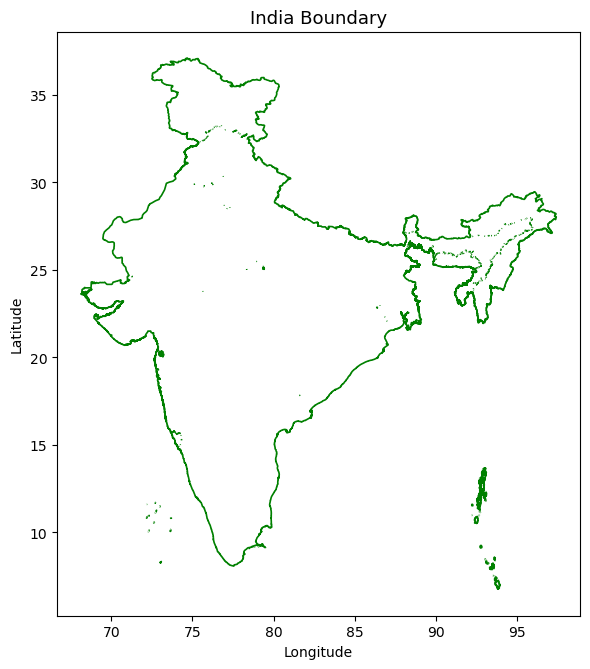

✅ Boundary plot saved.


In [ ]:
os.environ["SHAPE_RESTORE_SHX"] = "YES"

def load_india_boundary():
    try:
        gdf = gpd.read_file(BOUNDARY_SHP)
        if gdf.crs is None:
            gdf = gdf.set_crs("EPSG:3857")
        gdf = gdf.to_crs("EPSG:4326")
        dissolved = gpd.GeoDataFrame(
            {"name": ["India"]},
            geometry=[gdf.union_all()],
            crs="EPSG:4326",
        )
        print(f"✅ Boundary loaded from local shapefile ({len(gdf)} parts dissolved to 1)")
        return dissolved
    except Exception as e:
        print(f"⚠️  Could not load {BOUNDARY_SHP}: {e}")
        print("   Falling back to bounding-box rectangle.")
        from shapely.geometry import box
        return gpd.GeoDataFrame(
            {"name": ["India (bbox fallback)"]},
            geometry=[box(INDIA_BBOX["lon_min"], INDIA_BBOX["lat_min"],
                          INDIA_BBOX["lon_max"], INDIA_BBOX["lat_max"])],
            crs="EPSG:4326",
        )

india = load_india_boundary()
india.to_file(os.path.join(OUTPUT_DIR, "boundary", "india.gpkg"), driver="GPKG")
INDIA_POLYGON = india.geometry.iloc[0]

print(f"   Bounds : {india.total_bounds}")
print(f"   Valid  : {INDIA_POLYGON.is_valid}")

fig, ax = plt.subplots(1, 1, figsize=(6, 7))
india.boundary.plot(ax=ax, color="green", linewidth=1.2)
ax.set_title("India Boundary", fontsize=13)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plots", "india_boundary.png"), dpi=150)
plt.show()
print("✅ Boundary plot saved.")


## 🔥 Step 5 — Load & Clean MODIS Fire Archive
Loads `fire_archive_M-C61_772720.csv`, clips to the India bounding box (cheap
pre-filter) then to the *exact* India polygon from Step 4 (excludes fire points
in Sri Lanka / Nepal / Bangladesh / Myanmar / Pakistan that fall inside the
bounding box but outside India's real borders), clips to the study period,
removes duplicates, and saves the merged CSV.

In [ ]:
t0 = time.time()
print("Loading MODIS fire archive...")

df = pd.read_csv(FIRE_CSV_PATH, low_memory=False)
df.columns = [c.strip().lower() for c in df.columns]
print(f"  Raw rows            : {len(df):,}")

# ── Parse dates ─────────────────────────────────────────────
df["acq_date"] = pd.to_datetime(df["acq_date"], format="%Y-%m-%d", errors="coerce")
before = len(df)
df = df.dropna(subset=["acq_date", "latitude", "longitude"])
print(f"  After dropping invalid rows : {len(df):,}  (dropped {before-len(df):,})")

# ── Cheap bounding-box pre-filter ───────────────────────────────
df = df[
    (df["longitude"] >= INDIA_BBOX["lon_min"]) & (df["longitude"] <= INDIA_BBOX["lon_max"]) &
    (df["latitude"]  >= INDIA_BBOX["lat_min"])  & (df["latitude"]  <= INDIA_BBOX["lat_max"])
]
print(f"  After India bbox pre-filter : {len(df):,}")

# ── Exact India-polygon clip (excludes neighboring countries) ──
inside = shapely.contains_xy(INDIA_POLYGON, df["longitude"].values, df["latitude"].values)
n_excluded = (~inside).sum()
df = df[inside]
print(f"  After India polygon clip    : {len(df):,}  "
      f"(excluded {n_excluded:,} points outside India's actual borders)")

# ── Clip to study period ────────────────────────────────────────
df = df[(df["acq_date"] >= STUDY_START) & (df["acq_date"] <= STUDY_END)]
print(f"  After study period filter   : {len(df):,}  ({STUDY_START.date()} → {STUDY_END.date()})")

# ── Remove duplicates ────────────────────────────────────────────
df = df.drop_duplicates(subset=["longitude", "latitude", "acq_date"])
print(f"  After deduplication         : {len(df):,}")

df["year"]  = df["acq_date"].dt.year
df["month"] = df["acq_date"].dt.month

fire_all = df.reset_index(drop=True)

merged_path = os.path.join(OUTPUT_DIR, "all_fire_india_merged.csv")
fire_all.to_csv(merged_path, index=False)
MERGED_CSV_PATH = merged_path

print(f"\nSaved: {MERGED_CSV_PATH}")
print(f"Rows : {len(fire_all):,}")
print("\nAnnual fire counts:")
print(fire_all.groupby("year").size().to_string())
print(f"\nDone in {time.time()-t0:.1f}s")


Loading MODIS fire archive...
  Raw rows            : 2,804,373
  After dropping invalid rows : 2,804,373  (dropped 0)
  After India bbox pre-filter : 2,801,347
  After India polygon clip    : 1,599,471  (excluded 1,201,876 points outside India's actual borders)
  After study period filter   : 1,599,471  (2000-11-01 → 2022-12-15)
  After deduplication         : 1,599,466

Saved: D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\all_fire_india_merged.csv
Rows : 1,599,466

Annual fire counts:
year
2000      1419
2001     18844
2002     26939
2003     56119
2004     64757
2005     63737
2006     66195
2007     75413
2008     71025
2009     90500
2010     76894
2011     72441
2012     93536
2013     71219
2014     76638
2015     68553
2016     89354
2017     82729
2018     91342
2019     75693
2020     76149
2021    111467
2022     78503

Done in 8.6s


## 📦 Step 6 — Extract LULC ZIPs & Build Year → File Map
Scans all ZIPs in the LULC folder, extracts each year's NetCDF (skipping ones
already extracted), and fills any missing years (2000, 2012) with the nearest
available year — capped at 2022, matching the study period.

In [ ]:
extract_dir = os.path.join(OUTPUT_DIR, "lulc_extracted")
Path(extract_dir).mkdir(parents=True, exist_ok=True)

zip_files = sorted([
    os.path.join(LULC_DIR, f) for f in os.listdir(LULC_DIR)
    if f.lower().endswith(".zip")
])
print(f"Total ZIP files found: {len(zip_files)}")

lulc_year_map = {}   # {year: extracted_nc_full_path}

for zf_path in tqdm(zip_files, desc="Scanning/extracting ZIPs"):
    try:
        with zipfile.ZipFile(zf_path, "r") as zf:
            for item in zf.namelist():
                if not item.lower().endswith(".nc"):
                    continue
                nc_basename = os.path.basename(item)
                match = re.search(r"(19|20)\d{2}", nc_basename)
                if not match:
                    continue
                yr = int(match.group())
                if yr > END_YEAR:
                    continue   # ignore any years beyond the study period
                out_path = os.path.join(extract_dir, nc_basename)
                if not os.path.exists(out_path):
                    zf.extract(item, extract_dir)
                    nested = os.path.join(extract_dir, item)
                    if os.path.exists(nested) and nested != out_path:
                        os.makedirs(os.path.dirname(out_path), exist_ok=True)
                        os.rename(nested, out_path)
                lulc_year_map[yr] = out_path
    except Exception as e:
        print(f"  ERROR: {os.path.basename(zf_path)} -> {e}")

# ── Fill missing years with nearest available (capped at END_YEAR) ────
needed        = set(range(START_YEAR, END_YEAR + 1))
available_yrs = sorted(lulc_year_map.keys())
missing       = sorted(needed - set(available_yrs))

print(f"\nYears with real LULC data : {available_yrs}")
print(f"Missing years              : {missing}")

for y in missing:
    nearest = min(available_yrs, key=lambda x: abs(x - y))
    lulc_year_map[y] = lulc_year_map[nearest]
    print(f"  {y} -> using {nearest} LULC (nearest-year fallback)")

print(f"\n✅ Final LULC year map covers {len(lulc_year_map)} years "
      f"({START_YEAR}-{END_YEAR})")


Total ZIP files found: 31


Scanning/extracting ZIPs: 100%|██████████| 31/31 [00:00<?, ?it/s]


Years with real LULC data : [1992, 1993, 1994, 1995, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Missing years              : []

✅ Final LULC year map covers 27 years (2000-2022)


## 🚀 Step 7 — GPU-Accelerated Extraction Functions
For each year: load the LULC grid → build a binary forest mask on GPU → look up
the exact grid cell for every fire point via affine math (exact for ESA-CCI's
regular lat/lon grid — not an approximation) → keep only points that fall in a
forest pixel. All array math runs via `cp` (CuPy on GPU, NumPy fallback on CPU).

In [ ]:
def load_lulc_grid(nc_path):
    with nc_lib.Dataset(nc_path, "r") as ds:
        lulc = np.array(ds.variables["lccs_class"][:])
        lat  = np.array(ds.variables["lat"][:])
        lon  = np.array(ds.variables["lon"][:])
    if lulc.ndim == 3:
        lulc = lulc[0]     # drop time dimension
    return lulc, lat, lon


def build_forest_mask(lulc, forest_codes):
    lulc_dev  = cp.asarray(lulc)
    codes_dev = cp.asarray(sorted(forest_codes))
    return cp.isin(lulc_dev, codes_dev).astype(cp.uint8)


def points_to_pixel_indices(lat_arr, lon_arr, pt_lats, pt_lons):
    # Exact regular-grid row/col lookup via affine math (works for ascending
    # or descending lat/lon arrays, since it uses the array's own step size)
    lat_dev = cp.asarray(lat_arr)
    lon_dev = cp.asarray(lon_arr)
    pt_lat_dev = cp.asarray(np.asarray(pt_lats, dtype=np.float64))
    pt_lon_dev = cp.asarray(np.asarray(pt_lons, dtype=np.float64))

    dlat = float(lat_arr[1] - lat_arr[0])
    dlon = float(lon_arr[1] - lon_arr[0])

    row = cp.round((pt_lat_dev - lat_dev[0]) / dlat).astype(cp.int32)
    col = cp.round((pt_lon_dev - lon_dev[0]) / dlon).astype(cp.int32)

    row = cp.clip(row, 0, len(lat_arr) - 1)
    col = cp.clip(col, 0, len(lon_arr) - 1)
    return row, col


def extract_forest_fires(fire_year_df, nc_path, forest_codes):
    lulc, lat, lon = load_lulc_grid(nc_path)
    forest_mask = build_forest_mask(lulc, forest_codes)
    forest_pct  = float(100.0 * cp.sum(forest_mask == 1) / forest_mask.size)

    row, col = points_to_pixel_indices(
        lat, lon,
        fire_year_df[FIRE_LAT_COL].values,
        fire_year_df[FIRE_LON_COL].values,
    )
    is_forest = to_host(forest_mask[row, col].astype(bool))

    return fire_year_df[is_forest].copy(), forest_pct


print("✅ GPU extraction functions defined:")
print("   1. load_lulc_grid()          -> read NetCDF LULC grid")
print("   2. build_forest_mask()       -> binary forest mask (GPU)")
print("   3. points_to_pixel_indices() -> exact affine pixel lookup (GPU)")
print("   4. extract_forest_fires()    -> per-year forest fire point filter")


✅ GPU extraction functions defined:
   1. load_lulc_grid()          -> read NetCDF LULC grid
   2. build_forest_mask()       -> binary forest mask (GPU)
   3. points_to_pixel_indices() -> exact affine pixel lookup (GPU)
   4. extract_forest_fires()    -> per-year forest fire point filter


## 🔥 Step 8 — Run Main Extraction Loop (2000–2022)
Processes each year: LULC → forest mask (GPU) → pixel lookup (GPU) → annual +
monthly CSVs.

In [ ]:
summary = []
all_forest_fires = []

t0 = time.time()
print(f"Starting extraction ({'GPU: ' + gpu_name if GPU_AVAILABLE else 'CPU fallback'})")
print("=" * 70)

for year in tqdm(range(START_YEAR, END_YEAR + 1), desc="Years"):

    fire_yr = fire_all[fire_all["year"] == year].reset_index(drop=True)
    if len(fire_yr) == 0:
        print(f"  {year}: no fire points — skipping")
        continue

    nc_path = lulc_year_map.get(year)
    if not nc_path or not os.path.exists(nc_path):
        print(f"  {year}: no LULC file — skipping")
        continue

    try:
        ff_yr, forest_pct = extract_forest_fires(fire_yr, nc_path, FOREST_CODES)
    except Exception as e:
        print(f"  {year}: ERROR -> {e}")
        continue

    # ── Save annual CSV ────────────────────────────────────────
    ann_path = os.path.join(OUTPUT_DIR, "forest_fire_points", f"forest_fire_{year}.csv")
    ff_yr.to_csv(ann_path, index=False)
    all_forest_fires.append(ff_yr)

    # ── Save monthly CSVs ──────────────────────────────────────
    mon_dir = os.path.join(OUTPUT_DIR, "monthly_records", str(year))
    Path(mon_dir).mkdir(parents=True, exist_ok=True)
    for m in range(1, 13):
        mon_df = ff_yr[ff_yr["month"] == m]
        if len(mon_df) > 0:
            mon_df.to_csv(os.path.join(mon_dir, f"forest_fire_{year}_{m:02d}.csv"), index=False)

    summary.append({
        "year"             : year,
        "total_fire_points": len(fire_yr),
        "forest_fire_points": len(ff_yr),
        "forest_fire_pct"  : round(100 * len(ff_yr) / max(1, len(fire_yr)), 2),
        "forest_cover_pct" : round(forest_pct, 2),
    })

    print(f"  {year}: total={len(fire_yr):6,} | forest={len(ff_yr):6,} "
          f"({100*len(ff_yr)/max(1,len(fire_yr)):.1f}%) | cover={forest_pct:.1f}%")

elapsed = time.time() - t0

# ── Save combined outputs ──────────────────────────────────────
summary_df = pd.DataFrame(summary)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "extraction_summary.csv"), index=False)

if all_forest_fires:
    all_ff = pd.concat(all_forest_fires, ignore_index=True)
    all_ff_path = os.path.join(OUTPUT_DIR, f"all_forest_fires_{START_YEAR}_{END_YEAR}.csv")
    all_ff.to_csv(all_ff_path, index=False)
    print(f"\n✅ Total forest fire points extracted: {len(all_ff):,}")
    print(f"   Saved: {all_ff_path}")

print(f"\nAnnual summary:")
print(summary_df.to_string(index=False))
print(f"\nDone in {elapsed:.1f}s "
      f"({'GPU' if GPU_AVAILABLE else 'CPU'}-accelerated, {END_YEAR-START_YEAR+1} years)")


Starting extraction (GPU: NVIDIA RTX PRO 4500 Blackwell)


Years:   4%|▍         | 1/23 [00:00<00:13,  1.69it/s]

  2000: total= 1,419 | forest=   225 (15.9%) | cover=9.9%


Years:   9%|▊         | 2/23 [00:01<00:12,  1.73it/s]

  2001: total=18,844 | forest= 6,007 (31.9%) | cover=9.9%


...

Years:  96%|█████████▌| 22/23 [00:14<00:00,  1.45it/s]

  2021: total=111,467 | forest=38,116 (34.2%) | cover=10.3%


Years: 100%|██████████| 23/23 [00:15<00:00,  1.48it/s]

  2022: total=78,503 | forest=22,707 (28.9%) | cover=10.4%



✅ Total forest fire points extracted: 541,545
   Saved: D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv

Annual summary:
 year  total_fire_points  forest_fire_points  forest_fire_pct  forest_cover_pct
 2000               1419                 225            15.86              9.86
 2001              18844                6007            31.88              9.95
 2002              26939                4290            15.92              9.95
 2003              56119               22348            39.82              9.97
 2004              64757               28668            44.27             10.01
 2005              63737               22270            34.94             10.00
 2006              66195               27241            41.15             10.00
 2007              75413               29008            38.47             10.01
 2008              71025               23356            32.88             10.01
 2009              90500               40155 

## 📊 Step 9 — Summary Visualizations

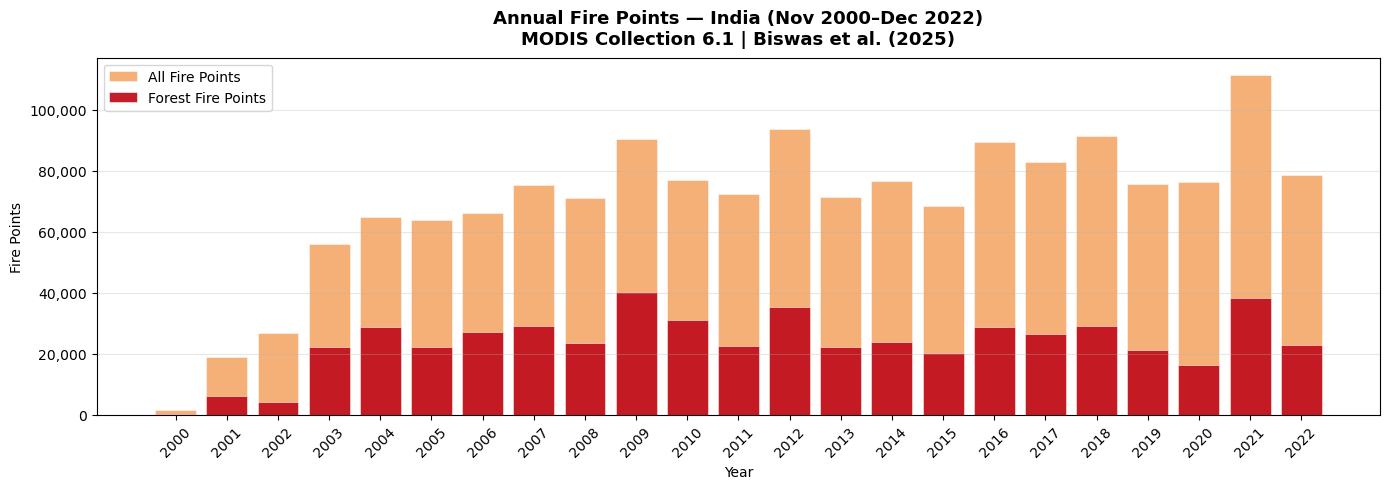

Plot 1 saved.


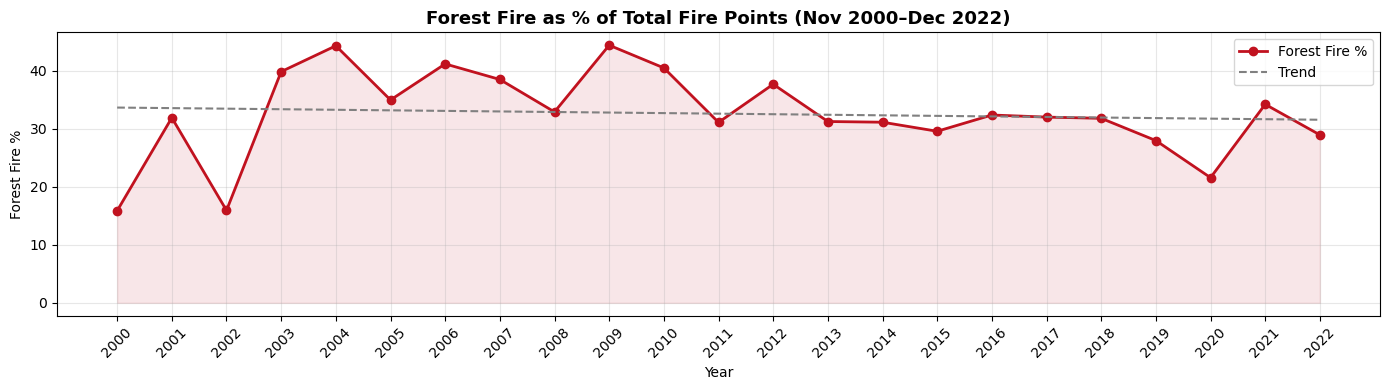

Plot 2 saved.


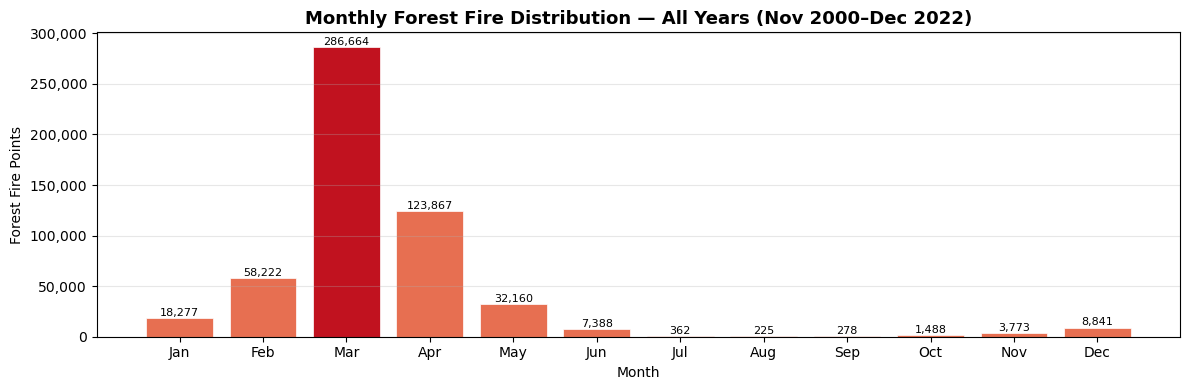

Plot 3 saved.


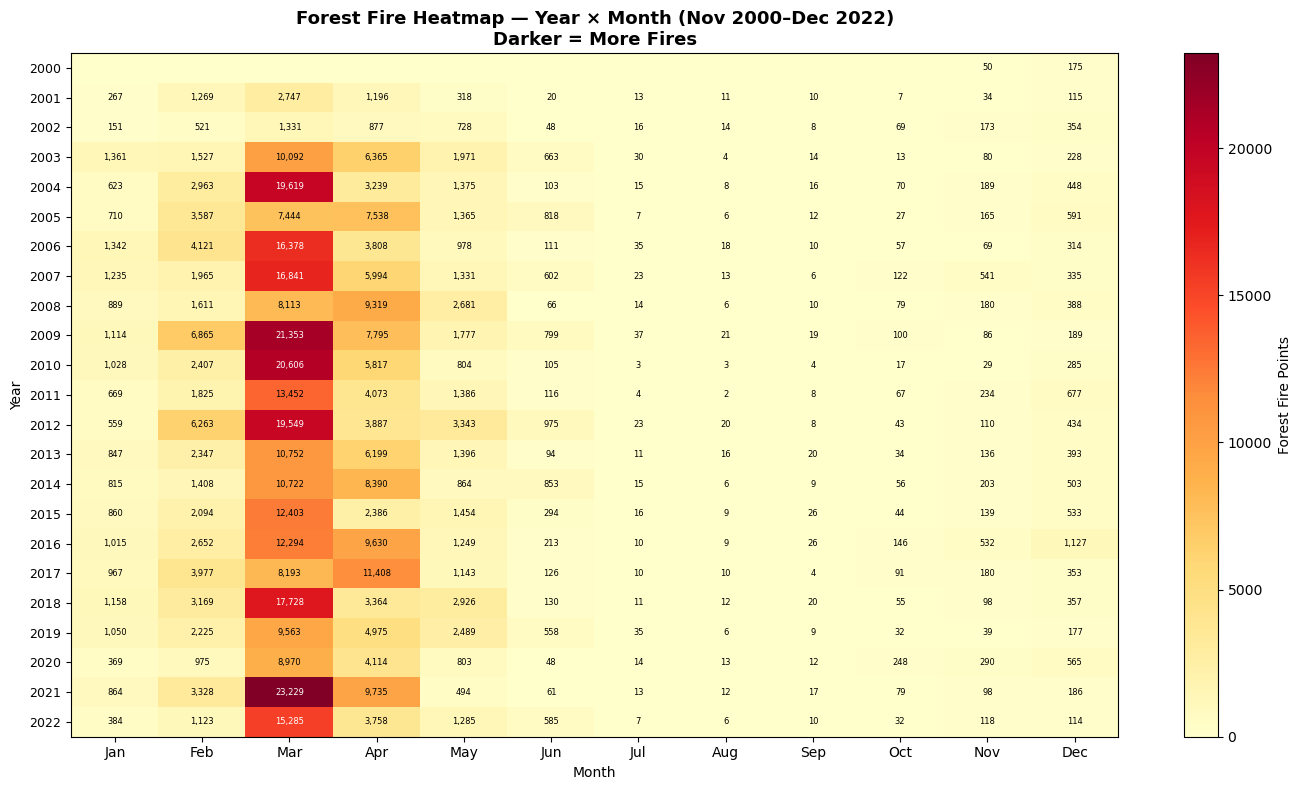

Plot 4 saved.


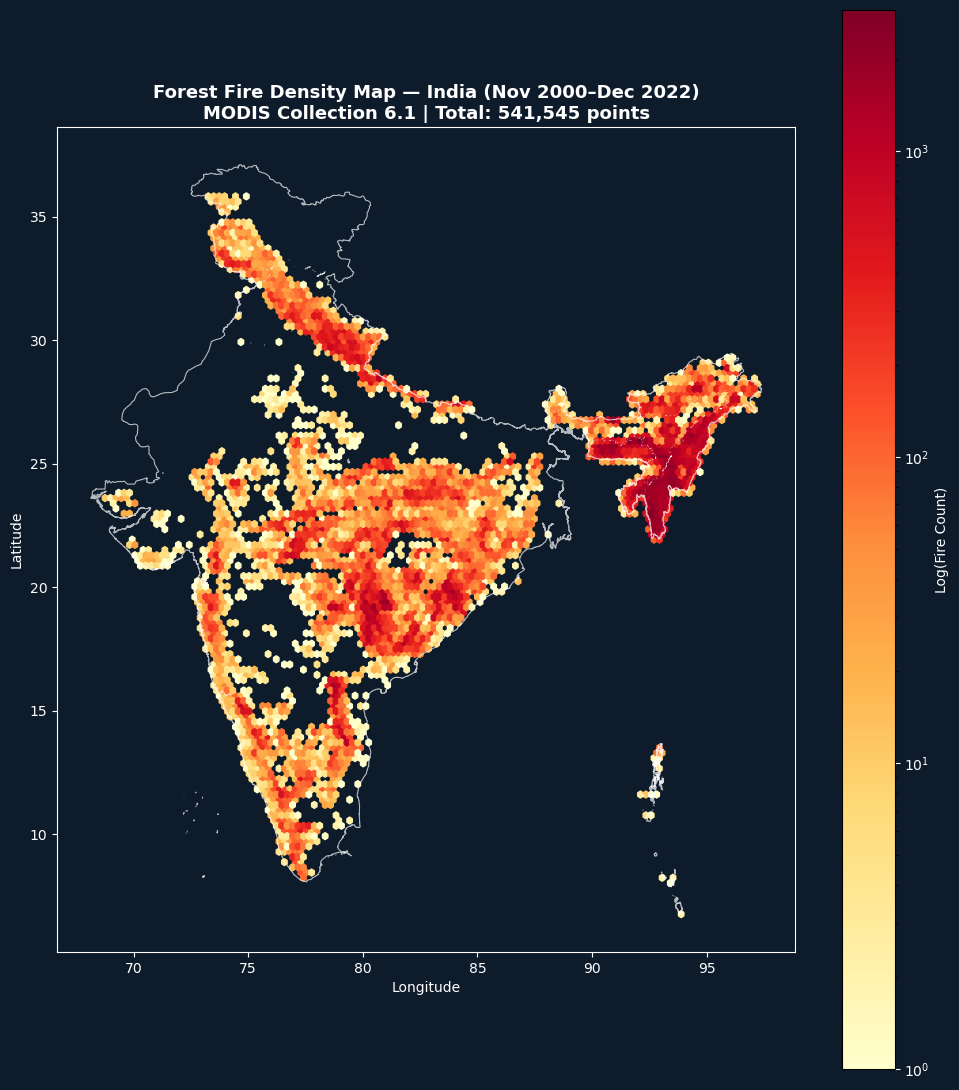

Plot 5 saved.


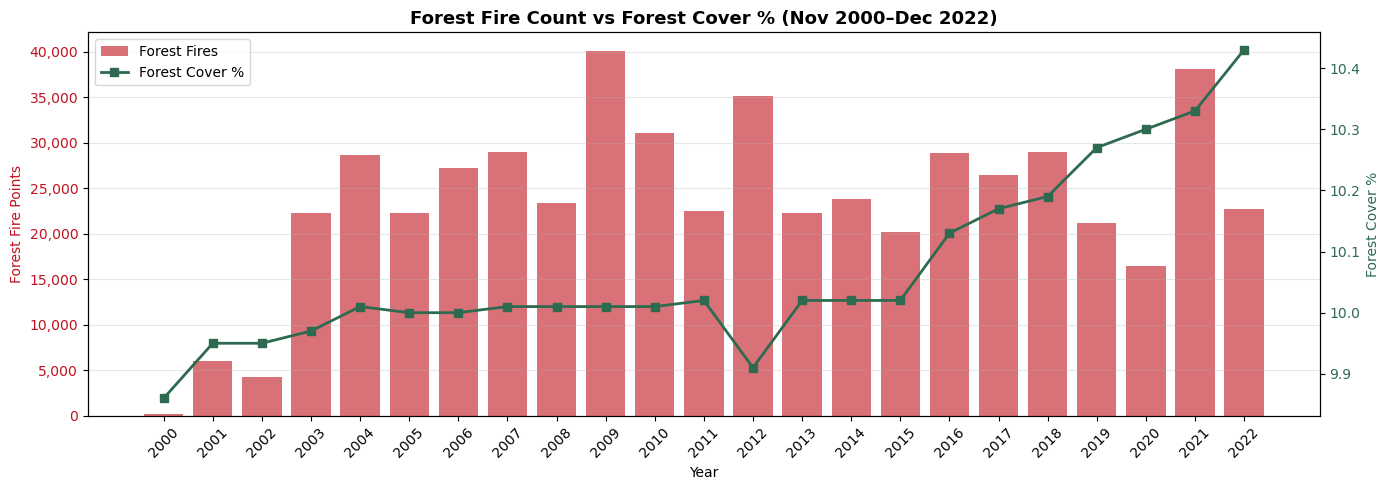

Plot 6 saved.

ALL 6 PLOTS SAVED TO: D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\plots


In [ ]:
plots_dir = os.path.join(OUTPUT_DIR, "plots")
fmt_k = mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
period_label = f"{STUDY_START.strftime('%b %Y')}–{STUDY_END.strftime('%b %Y')}"
total_forest_fires = len(all_ff)

# PLOT 1 — Annual fire counts: total vs forest
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(summary_df["year"], summary_df["total_fire_points"],
       color="#f4a261", alpha=0.85, label="All Fire Points", edgecolor="white", linewidth=0.4)
ax.bar(summary_df["year"], summary_df["forest_fire_points"],
       color="#c1121f", alpha=0.95, label="Forest Fire Points", edgecolor="white", linewidth=0.4)
ax.set_title(f"Annual Fire Points — India ({period_label})\nMODIS Collection 6.1 | Biswas et al. (2025)",
             fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("Year"); ax.set_ylabel("Fire Points")
ax.set_xticks(summary_df["year"]); ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(fmt_k)
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "01_annual_fire_counts.png"), dpi=150, bbox_inches="tight")
plt.show(); print("Plot 1 saved.")

# PLOT 2 — Forest fire % trend
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(summary_df["year"], summary_df["forest_fire_pct"], "o-", color="#c1121f",
        linewidth=2, markersize=6, label="Forest Fire %")
z = np.polyfit(summary_df["year"], summary_df["forest_fire_pct"], 1)
ax.plot(summary_df["year"], np.poly1d(z)(summary_df["year"]), "--", color="gray",
        linewidth=1.5, label="Trend")
ax.fill_between(summary_df["year"], summary_df["forest_fire_pct"], alpha=0.1, color="#c1121f")
ax.set_title(f"Forest Fire as % of Total Fire Points ({period_label})", fontsize=13, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Forest Fire %")
ax.set_xticks(summary_df["year"]); ax.tick_params(axis="x", rotation=45)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "02_forest_fire_pct_trend.png"), dpi=150, bbox_inches="tight")
plt.show(); print("Plot 2 saved.")

# PLOT 3 — Monthly distribution
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = all_ff.groupby("month").size().reindex(range(1, 13), fill_value=0)
fig, ax = plt.subplots(figsize=(12, 4))
colors = ["#c1121f" if v == monthly.max() else "#e76f51" for v in monthly.values]
bars = ax.bar(month_names, monthly.values, color=colors, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, monthly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300, f"{val:,}",
            ha="center", va="bottom", fontsize=8)
ax.set_title(f"Monthly Forest Fire Distribution — All Years ({period_label})", fontsize=13, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Forest Fire Points")
ax.yaxis.set_major_formatter(fmt_k); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "03_monthly_distribution.png"), dpi=150, bbox_inches="tight")
plt.show(); print("Plot 3 saved.")

# PLOT 4 — Year x Month heatmap
pivot = all_ff.groupby(["year","month"]).size().unstack(fill_value=0)
pivot.columns = month_names[:pivot.shape[1]]
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index.astype(int), fontsize=9)
plt.colorbar(im, ax=ax, label="Forest Fire Points")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, f"{val:,}", ha="center", va="center", fontsize=6,
                    color="white" if val > pivot.values.max()*0.6 else "black")
ax.set_title(f"Forest Fire Heatmap — Year × Month ({period_label})\nDarker = More Fires",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Year")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "04_year_month_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show(); print("Plot 4 saved.")

# PLOT 5 — Spatial density map
fig, ax = plt.subplots(figsize=(10, 11))
ax.set_facecolor("#0d1b2a"); fig.patch.set_facecolor("#0d1b2a")
hb = ax.hexbin(all_ff["longitude"], all_ff["latitude"], gridsize=120, cmap="YlOrRd", mincnt=1, bins="log")
cb = plt.colorbar(hb, ax=ax, label="Log(Fire Count)")
cb.ax.yaxis.label.set_color("white"); cb.ax.tick_params(colors="white")
try:
    india_gdf = gpd.read_file(os.path.join(OUTPUT_DIR, "boundary", "india.gpkg"))
    india_gdf.boundary.plot(ax=ax, color="white", linewidth=0.8, alpha=0.7)
except Exception as e:
    print(f"Boundary file could not be loaded: {e}")
    ax.set_xlim(68, 98); ax.set_ylim(6, 38)
ax.set_title(f"Forest Fire Density Map — India ({period_label})\nMODIS Collection 6.1 | Total: {total_forest_fires:,} points",
             fontsize=13, fontweight="bold", color="white")
ax.set_xlabel("Longitude", color="white"); ax.set_ylabel("Latitude", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("white")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "05_spatial_density_map.png"), dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show(); print("Plot 5 saved.")

# PLOT 6 — Forest fire count vs forest cover %
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.bar(summary_df["year"], summary_df["forest_fire_points"], color="#c1121f", alpha=0.6, label="Forest Fires")
ax2.plot(summary_df["year"], summary_df["forest_cover_pct"], "s-", color="#2d6a4f",
         linewidth=2, markersize=6, label="Forest Cover %")
ax1.set_xlabel("Year"); ax1.set_ylabel("Forest Fire Points", color="#c1121f")
ax2.set_ylabel("Forest Cover %", color="#2d6a4f")
ax1.tick_params(axis="y", labelcolor="#c1121f"); ax2.tick_params(axis="y", labelcolor="#2d6a4f")
ax1.set_xticks(summary_df["year"]); ax1.tick_params(axis="x", rotation=45)
ax1.yaxis.set_major_formatter(fmt_k)
ax1.set_title(f"Forest Fire Count vs Forest Cover % ({period_label})", fontsize=13, fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)
ax1.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "06_fire_vs_forest_cover.png"), dpi=150, bbox_inches="tight")
plt.show(); print("Plot 6 saved.")

print("\n" + "="*55)
print("ALL 6 PLOTS SAVED TO:", plots_dir)
print("="*55)


## ✅ Step 10 — Final Output Summary

In [ ]:
print("=" * 65)
print("  PIPELINE COMPLETE — OUTPUT SUMMARY")
print("=" * 65)
print(f"  Study period : {STUDY_START.date()} → {STUDY_END.date()}")
print(f"  Compute      : {'GPU (' + gpu_name + ')' if GPU_AVAILABLE else 'CPU (NumPy fallback)'}")
print()

output_files = {
    "Merged fire CSV (all years)"   : "all_fire_india_merged.csv",
    "Forest fires CSV (all years)"  : f"all_forest_fires_{START_YEAR}_{END_YEAR}.csv",
    "Extraction summary"            : "extraction_summary.csv",
}

for label, fname in output_files.items():
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / (1024*1024)
        df_tmp = pd.read_csv(fpath)
        print(f"  ✅ {label}")
        print(f"     Path : {fpath}")
        print(f"     Size : {size:.2f} MB  |  Rows: {len(df_tmp):,}")
    else:
        print(f"  ⚠️  Not found: {fpath}")
    print()

annual_csvs  = list(Path(os.path.join(OUTPUT_DIR, "forest_fire_points")).glob("*.csv"))
monthly_csvs = list(Path(os.path.join(OUTPUT_DIR, "monthly_records")).rglob("*.csv"))
print(f"  ✅ Annual forest-fire CSVs : {len(annual_csvs)} files")
print(f"  ✅ Monthly CSV files       : {len(monthly_csvs)} files")
print()
print(f"  📂 All outputs in: {OUTPUT_DIR}")
print("=" * 65)


  PIPELINE COMPLETE — OUTPUT SUMMARY
  Study period : 2000-11-01 → 2022-12-15
  Compute      : GPU (NVIDIA RTX PRO 4500 Blackwell)

  ✅ Merged fire CSV (all years)
     Path : D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\all_fire_india_merged.csv
     Size : 133.05 MB  |  Rows: 1,599,466

  ✅ Forest fires CSV (all years)
     Path : D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv
     Size : 44.95 MB  |  Rows: 541,545

  ✅ Extraction summary
     Path : D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs\extraction_summary.csv
     Size : 0.00 MB  |  Rows: 23

  ✅ Annual forest-fire CSVs : 23 files
  ✅ Monthly CSV files       : 266 files

  📂 All outputs in: D:\FOREST FIRE MAPPING(INDIA)\Forest_Fire_Outputs
